# Tuning des paramètres — Algorithme Génétique VRPTW
## Analyse par taille de problème : n = 10, 20, 50, 100, 200

> **Objectif** : Trouver les paramètres optimaux d'**intensification** et de **diversification** pour chaque taille de problème.
>
> | Famille | Paramètres étudiés | Rôle |
> |---|---|---|
> | **Intensification** | `n_generations`, `taille_pop` | Exploiter les bonnes solutions — converger |
> | **Diversification** | `taux_mutation` | Explorer de nouvelles régions — éviter les optima locaux |
>
> **Hypothèse centrale** : les paramètres optimaux dépendent de n, car l'espace de recherche croît en O((n/K)!·K).
>
> **Temps estimé** : n=10→2min · n=20→3min · n=50→8min · n=100→15min · n=200→30min

---

## Table des matières
1. [Setup & instances](#1)
2. [Effet de `n_generations` par taille](#2)
3. [Effet de `taux_mutation` par taille](#3)
4. [Effet de `taille_pop` par taille](#4)
5. [Grid search gen × mut par taille](#5)
6. [Courbes de convergence comparées](#6)
7. [Bilan & configuration recommandée par taille](#7)

---
<a id='1'></a>
## 1. Setup & instances

In [1]:
import sys, os, json, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Chemins ───────────────────────────────────────────────────────
# Notebook : .../Projet/Phase 3/Algo_genetic/
GA_DIR    = os.path.abspath('.')
PHASE4    = os.path.abspath(os.path.join('..', '..', 'Phase 4'))
BENCH_DIR = os.path.abspath(os.path.join('..', '..', 'Benchmark'))

for p in [GA_DIR, PHASE4]:
    if p not in sys.path:
        sys.path.insert(0, p)

import importlib, genetic_algorithm as ga_module
importlib.reload(ga_module)
from genetic_algorithm import algorithme_genetique

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# ── Tailles et seeds ──────────────────────────────────────────────
# Plus n est grand, moins on peut se permettre de runs par config
# (temps de calcul croissant)
TAILLES = [10, 20, 50, 100, 200]

N_SEEDS_PAR_TAILLE = {
    10:  15,   # ~0.3s/run → rapide
    20:  10,   # ~0.7s/run
    50:   5,   # ~3.5s/run
    100:  3,   # ~30s/run
    200:  2,   # ~200s/run
}

# ── Chargement des instances ──────────────────────────────────────
with open(os.path.join(BENCH_DIR, 'results', 'oracle_results.json')) as f:
    oracle_data = json.load(f)

def load_instance(n, seed):
    path = os.path.join(BENCH_DIR, 'instances', f'n{n}', f'instance_n{n}_seed{seed}.json')
    with open(path) as f:
        d = json.load(f)
    return {
        'n': d['n'], 'n_vehicles': d['n_vehicles'],
        'coords':       np.array(d['coords']),
        'dist':         np.array(d['dist']),
        'durees':       np.array(d['durees']),
        'demands':      np.array(d['demands']),
        'capacity':     d['capacity'],
        'time_windows': np.array(d['time_windows']),
        'service_times':np.array(d['service_times']),
        'horizon':      d['horizon'],
    }

# Pré-charger toutes les instances nécessaires
ALL_INSTANCES = {}
ALL_ORACLES   = {}
for n in TAILLES:
    n_seeds = N_SEEDS_PAR_TAILLE[n]
    ALL_INSTANCES[n] = {s: load_instance(n, s) for s in range(n_seeds)}
    ALL_ORACLES[n]   = {s: oracle_data[f'n{n}_seed{s}']['cost'] for s in range(n_seeds)}

print("Instances chargées :")
for n in TAILLES:
    ns = N_SEEDS_PAR_TAILLE[n]
    print(f"  n={n:4d} : {ns} seeds | oracle moy = {np.mean(list(ALL_ORACLES[n].values())):.1f}")

# ── Fonction utilitaire centrale ──────────────────────────────────
def run_config(n, taille_pop, n_generations, taux_mutation):
    """
    Lance la config sur les N_SEEDS_PAR_TAILLE[n] instances de taille n.
    Retourne gap_moy, gap_std, gap_min, gap_max, t_moy et la liste des gaps.
    """
    n_seeds  = N_SEEDS_PAR_TAILLE[n]
    gaps, times = [], []
    for s in range(n_seeds):
        t0 = time.time()
        sol, cout, hist = algorithme_genetique(
            ALL_INSTANCES[n][s], seed=s,
            taille_pop=taille_pop,
            n_generations=n_generations,
            taux_mutation=taux_mutation,
        )
        gap = (cout - ALL_ORACLES[n][s]) / ALL_ORACLES[n][s] * 100
        gaps.append(gap)
        times.append(time.time() - t0)
    return {
        'gap_moy': np.mean(gaps), 'gap_med': np.median(gaps),
        'gap_std': np.std(gaps),  'gap_min': np.min(gaps),
        'gap_max': np.max(gaps),  't_moy':   np.mean(times),
        'gaps': gaps,
    }

# ── Configurations de référence par taille ────────────────────────
BASELINES = {
    10:  dict(taille_pop=30,  n_generations=100, taux_mutation=0.30),
    20:  dict(taille_pop=30,  n_generations=100, taux_mutation=0.30),
    50:  dict(taille_pop=40,  n_generations=150, taux_mutation=0.30),
    100: dict(taille_pop=50,  n_generations=200, taux_mutation=0.25),
    200: dict(taille_pop=60,  n_generations=200, taux_mutation=0.20),
}

print("\nBaseline par taille (référence) :")
BASE_RESULTS = {}
for n in TAILLES:
    r = run_config(n, **BASELINES[n])
    BASE_RESULTS[n] = r
    print(f"  n={n:4d} : gap_moy={r['gap_moy']:+.2f}%  gap_std={r['gap_std']:.2f}%  t={r['t_moy']:.2f}s")

Instances chargées :
  n=  10 : 15 seeds | oracle moy = 401.4
  n=  20 : 10 seeds | oracle moy = 569.2
  n=  50 : 5 seeds | oracle moy = 894.1
  n= 100 : 3 seeds | oracle moy = 1457.9
  n= 200 : 2 seeds | oracle moy = 2355.3

Baseline par taille (référence) :
  n=  10 : gap_moy=+13.28%  gap_std=6.06%  t=0.36s
  n=  20 : gap_moy=+38.61%  gap_std=11.74%  t=0.66s
  n=  50 : gap_moy=+67.74%  gap_std=9.04%  t=3.48s
  n= 100 : gap_moy=+109.10%  gap_std=11.10%  t=10.33s
  n= 200 : gap_moy=+154.34%  gap_std=6.20%  t=23.97s


---
<a id='2'></a>
## 2. Effet de `n_generations` par taille — Intensification

**Hypothèse :** Plus n est grand, plus il faut de générations pour converger.
Le plateau de convergence arrive de plus en plus tard quand l'espace de recherche grandit.


n=10 (pop=30, mut=0.3) :
  gen=  25  gap=+16.66%  ±4.99%  t=0.1s
  gen=  50  gap=+14.72%  ±6.41%  t=0.2s
  gen= 100  gap=+13.28%  ±6.06%  t=0.4s
  gen= 200  gap=+11.12%  ±6.27%  t=0.7s
  gen= 400  gap= +8.24%  ±7.55%  t=1.4s

n=20 (pop=30, mut=0.3) :
  gen=  25  gap=+41.06%  ±14.50%  t=0.2s
  gen=  50  gap=+41.25%  ±14.52%  t=0.3s
  gen= 100  gap=+38.61%  ±11.74%  t=0.7s
  gen= 200  gap=+40.73%  ±11.38%  t=1.3s
  gen= 400  gap=+35.82%  ±13.75%  t=2.6s

n=50 (pop=40, mut=0.3) :
  gen=  50  gap=+70.96%  ±10.78%  t=1.2s
  gen= 100  gap=+66.55%  ±7.86%  t=2.5s
  gen= 200  gap=+68.18%  ±9.26%  t=4.6s
  gen= 350  gap=+61.73%  ±10.21%  t=8.1s

n=100 (pop=50, mut=0.25) :
  gen= 100  gap=+108.78%  ±5.23%  t=5.1s
  gen= 200  gap=+109.10%  ±11.10%  t=10.8s
  gen= 350  gap=+113.42%  ±10.42%  t=18.0s

n=200 (pop=60, mut=0.2) :
  gen= 100  gap=+155.12%  ±5.42%  t=12.6s
  gen= 200  gap=+154.34%  ±6.20%  t=24.1s
  gen= 350  gap=+147.76%  ±0.38%  t=41.8s


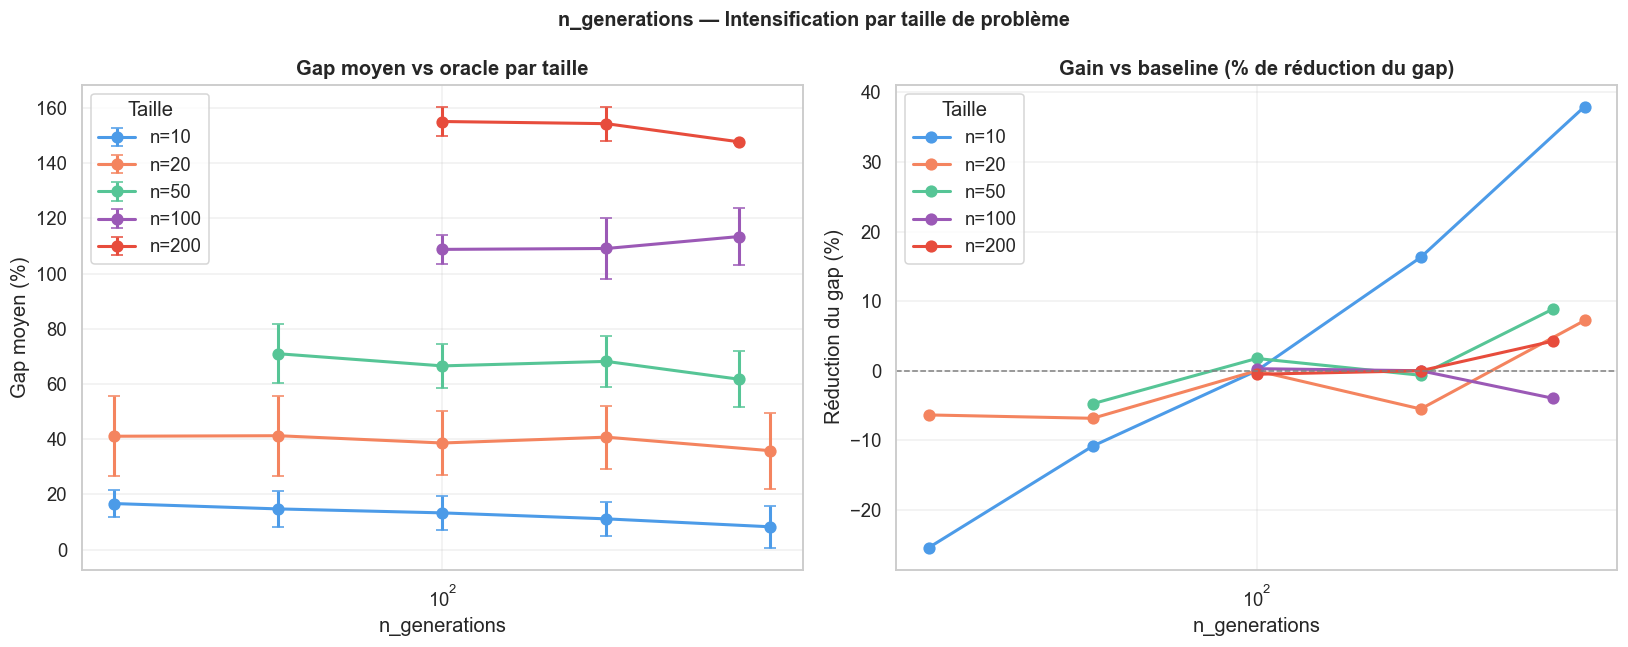


N_generations optimal par taille :
  n=  10 : gen_opt= 400  gap=+8.24%  (baseline +13.28%  gain=+5.04pts)
  n=  20 : gen_opt= 400  gap=+35.82%  (baseline +38.61%  gain=+2.79pts)
  n=  50 : gen_opt= 350  gap=+61.73%  (baseline +67.74%  gain=+6.01pts)
  n= 100 : gen_opt= 100  gap=+108.78%  (baseline +109.10%  gain=+0.32pts)
  n= 200 : gen_opt= 350  gap=+147.76%  (baseline +154.34%  gain=+6.57pts)


In [2]:
# Valeurs de n_generations testées — adaptées par taille pour limiter le temps
GEN_PAR_TAILLE = {
    10:  [25, 50, 100, 200, 400],
    20:  [25, 50, 100, 200, 400],
    50:  [50, 100, 200, 350],
    100: [100, 200, 350],
    200: [100, 200, 350],
}

results_gen = {n: [] for n in TAILLES}

for n in TAILLES:
    pop  = BASELINES[n]['taille_pop']
    mut  = BASELINES[n]['taux_mutation']
    print(f"\nn={n} (pop={pop}, mut={mut}) :")
    for gen in GEN_PAR_TAILLE[n]:
        r = run_config(n, taille_pop=pop, n_generations=gen, taux_mutation=mut)
        r['n_generations'] = gen
        results_gen[n].append(r)
        print(f"  gen={gen:4d}  gap={r['gap_moy']:+6.2f}%  ±{r['gap_std']:.2f}%  t={r['t_moy']:.1f}s")

# ── Visualisation ─────────────────────────────────────────────────
colors_n = {10:'#4C9BE8', 20:'#F4845F', 50:'#56C596', 100:'#9B59B6', 200:'#E74C3C'}
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for n in TAILLES:
    gens     = [r['n_generations'] for r in results_gen[n]]
    gap_moy  = [r['gap_moy']       for r in results_gen[n]]
    gap_std  = [r['gap_std']       for r in results_gen[n]]
    base_gap = BASE_RESULTS[n]['gap_moy']
    c = colors_n[n]

    # Axe gauche : gap moyen absolu
    axes[0].errorbar(gens, gap_moy, yerr=gap_std, fmt='o-',
                     color=c, linewidth=2, capsize=4, markersize=7,
                     label=f'n={n}')

    # Axe droit : amélioration relative vs baseline (0 = baseline)
    gain = [(base_gap - g) / base_gap * 100 for g in gap_moy]
    axes[1].plot(gens, gain, 'o-', color=c, linewidth=2, markersize=7, label=f'n={n}')

axes[0].set_title('Gap moyen vs oracle par taille', fontweight='bold')
axes[0].set_xlabel('n_generations')
axes[0].set_ylabel('Gap moyen (%)')
axes[0].legend(title='Taille')
axes[0].set_xscale('log')

axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Gain vs baseline (% de réduction du gap)', fontweight='bold')
axes[1].set_xlabel('n_generations')
axes[1].set_ylabel('Réduction du gap (%)')
axes[1].legend(title='Taille')
axes[1].set_xscale('log')

for ax in axes:
    ax.grid(alpha=0.3)

plt.suptitle('n_generations — Intensification par taille de problème',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Résumé : n_generations optimal par taille
print("\nN_generations optimal par taille :")
for n in TAILLES:
    best = min(results_gen[n], key=lambda r: r['gap_moy'])
    base = BASE_RESULTS[n]['gap_moy']
    gain = base - best['gap_moy']
    print(f"  n={n:4d} : gen_opt={best['n_generations']:4d}  gap={best['gap_moy']:+.2f}%  "
          f"(baseline {base:+.2f}%  gain={gain:+.2f}pts)")

---
<a id='3'></a>
## 3. Effet de `taux_mutation` par taille — Diversification

**Hypothèse :** La mutation optimale diminue avec n.
Sur un grand espace, une mutation trop forte détruit les bonnes solutions avant qu'elles soient exploitées.


n=10 (pop=30, gen=100) :
  mut=0.05  gap=+14.58%  ±6.73%
  mut=0.10  gap=+13.58%  ±7.50%
  mut=0.20  gap=+12.60%  ±7.12%
  mut=0.30  gap=+13.28%  ±6.06%
  mut=0.50  gap= +9.28%  ±6.44%
  mut=0.70  gap= +9.65%  ±6.24%

n=20 (pop=30, gen=100) :
  mut=0.05  gap=+38.49%  ±9.29%
  mut=0.10  gap=+39.55%  ±8.90%
  mut=0.20  gap=+41.28%  ±8.01%
  mut=0.30  gap=+38.61%  ±11.74%
  mut=0.50  gap=+41.28%  ±12.10%
  mut=0.70  gap=+42.43%  ±12.59%

n=50 (pop=40, gen=150) :
  mut=0.05  gap=+70.72%  ±7.56%
  mut=0.10  gap=+69.66%  ±7.35%
  mut=0.20  gap=+70.45%  ±9.13%
  mut=0.30  gap=+67.74%  ±9.04%
  mut=0.50  gap=+73.01%  ±8.84%
  mut=0.70  gap=+71.88%  ±7.24%

n=100 (pop=50, gen=200) :
  mut=0.05  gap=+112.74%  ±11.35%
  mut=0.10  gap=+103.88%  ±9.25%
  mut=0.20  gap=+108.34%  ±11.97%
  mut=0.30  gap=+102.53%  ±9.65%
  mut=0.50  gap=+104.58%  ±16.45%
  mut=0.70  gap=+107.70%  ±14.16%

n=200 (pop=60, gen=200) :
  mut=0.05  gap=+152.76%  ±2.32%
  mut=0.10  gap=+151.25%  ±9.53%
  mut=0.20  gap=+154.

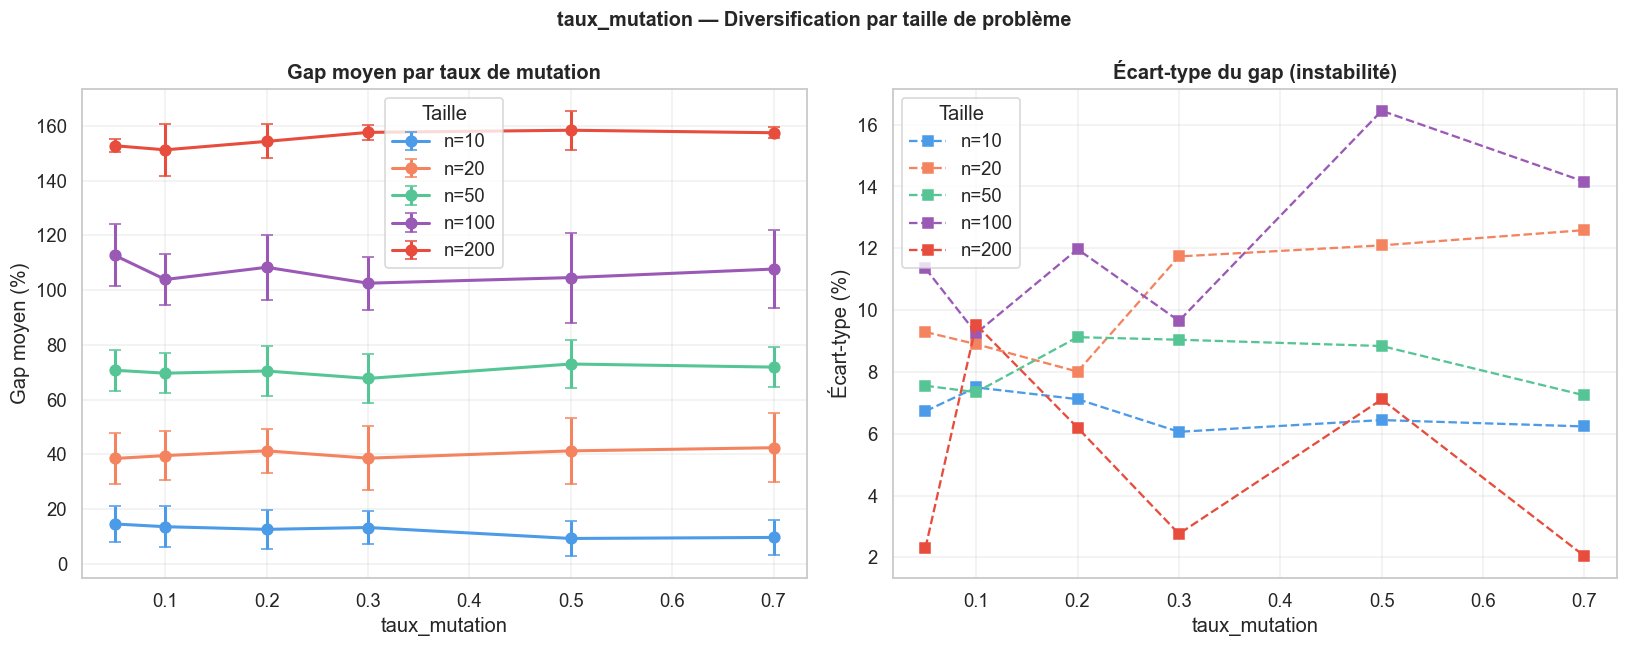

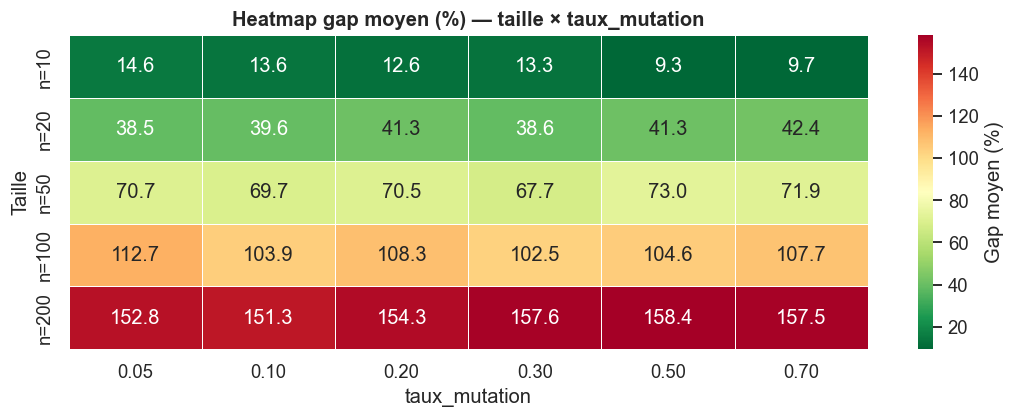


Mutation optimale par taille :
  n=  10 : mut_opt=0.50  gap=+9.28%
  n=  20 : mut_opt=0.05  gap=+38.49%
  n=  50 : mut_opt=0.30  gap=+67.74%
  n= 100 : mut_opt=0.30  gap=+102.53%
  n= 200 : mut_opt=0.10  gap=+151.25%


In [3]:
MUT_VALS = [0.05, 0.10, 0.20, 0.30, 0.50, 0.70]

results_mut = {n: [] for n in TAILLES}

for n in TAILLES:
    pop = BASELINES[n]['taille_pop']
    gen = BASELINES[n]['n_generations']
    print(f"\nn={n} (pop={pop}, gen={gen}) :")
    for mut in MUT_VALS:
        r = run_config(n, taille_pop=pop, n_generations=gen, taux_mutation=mut)
        r['taux_mutation'] = mut
        results_mut[n].append(r)
        print(f"  mut={mut:.2f}  gap={r['gap_moy']:+6.2f}%  ±{r['gap_std']:.2f}%")

# ── Visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for n in TAILLES:
    muts    = [r['taux_mutation'] for r in results_mut[n]]
    gap_moy = [r['gap_moy']      for r in results_mut[n]]
    gap_std = [r['gap_std']      for r in results_mut[n]]
    c = colors_n[n]

    axes[0].errorbar(muts, gap_moy, yerr=gap_std, fmt='o-',
                     color=c, linewidth=2, capsize=4, markersize=7, label=f'n={n}')
    axes[1].plot(muts, gap_std, 's--', color=c, linewidth=1.5, markersize=6, label=f'n={n}')

axes[0].set_title('Gap moyen par taux de mutation', fontweight='bold')
axes[0].set_xlabel('taux_mutation')
axes[0].set_ylabel('Gap moyen (%)')
axes[0].legend(title='Taille')

axes[1].set_title('Écart-type du gap (instabilité)', fontweight='bold')
axes[1].set_xlabel('taux_mutation')
axes[1].set_ylabel('Écart-type (%)')
axes[1].legend(title='Taille')

for ax in axes:
    ax.grid(alpha=0.3)

plt.suptitle('taux_mutation — Diversification par taille de problème',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Heatmap : gap_moy par (n, mut)
mat = np.array([[r['gap_moy'] for r in results_mut[n]] for n in TAILLES])
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(mat,
            xticklabels=[f"{m:.2f}" for m in MUT_VALS],
            yticklabels=[f"n={n}" for n in TAILLES],
            annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Gap moyen (%)'},
            ax=ax)
ax.set_title('Heatmap gap moyen (%) — taille × taux_mutation', fontweight='bold')
ax.set_xlabel('taux_mutation')
ax.set_ylabel('Taille')
plt.tight_layout()
plt.show()

print("\nMutation optimale par taille :")
for n in TAILLES:
    best = min(results_mut[n], key=lambda r: r['gap_moy'])
    print(f"  n={n:4d} : mut_opt={best['taux_mutation']:.2f}  gap={best['gap_moy']:+.2f}%")

---
<a id='4'></a>
## 4. Effet de `taille_pop` par taille — Intensification / Diversification

**Hypothèse :** Une population plus grande apporte plus de diversité génétique initiale, mais coûte plus cher par génération.
L'impact relatif devrait être plus fort pour les grandes instances où la diversité est cruciale.


n=10 (gen=100, mut=0.3) :
  pop= 10  gap=+15.90%  ±6.43%  t=0.1s
  pop= 20  gap=+13.30%  ±6.87%  t=0.2s
  pop= 30  gap=+13.28%  ±6.06%  t=0.4s
  pop= 50  gap= +6.84%  ±5.85%  t=0.6s
  pop= 80  gap= +8.82%  ±6.56%  t=1.0s

n=20 (gen=100, mut=0.3) :
  pop= 10  gap=+41.90%  ±12.20%  t=0.2s
  pop= 20  gap=+40.96%  ±11.73%  t=0.4s
  pop= 30  gap=+38.61%  ±11.74%  t=0.7s
  pop= 50  gap=+41.52%  ±10.66%  t=1.1s
  pop= 80  gap=+36.17%  ±9.19%  t=1.9s

n=50 (gen=150, mut=0.3) :
  pop= 20  gap=+72.17%  ±7.58%  t=1.7s
  pop= 30  gap=+74.07%  ±10.86%  t=2.6s
  pop= 40  gap=+67.74%  ±9.04%  t=3.6s
  pop= 60  gap=+72.45%  ±5.30%  t=5.2s
  pop= 80  gap=+69.36%  ±10.46%  t=7.1s

n=100 (gen=200, mut=0.25) :
  pop= 30  gap=+101.72%  ±11.64%  t=6.1s
  pop= 50  gap=+109.10%  ±11.10%  t=10.5s
  pop= 70  gap=+104.28%  ±4.15%  t=14.4s

n=200 (gen=200, mut=0.2) :
  pop= 40  gap=+154.51%  ±1.98%  t=16.0s
  pop= 60  gap=+154.34%  ±6.20%  t=24.3s
  pop= 80  gap=+160.56%  ±0.14%  t=32.3s


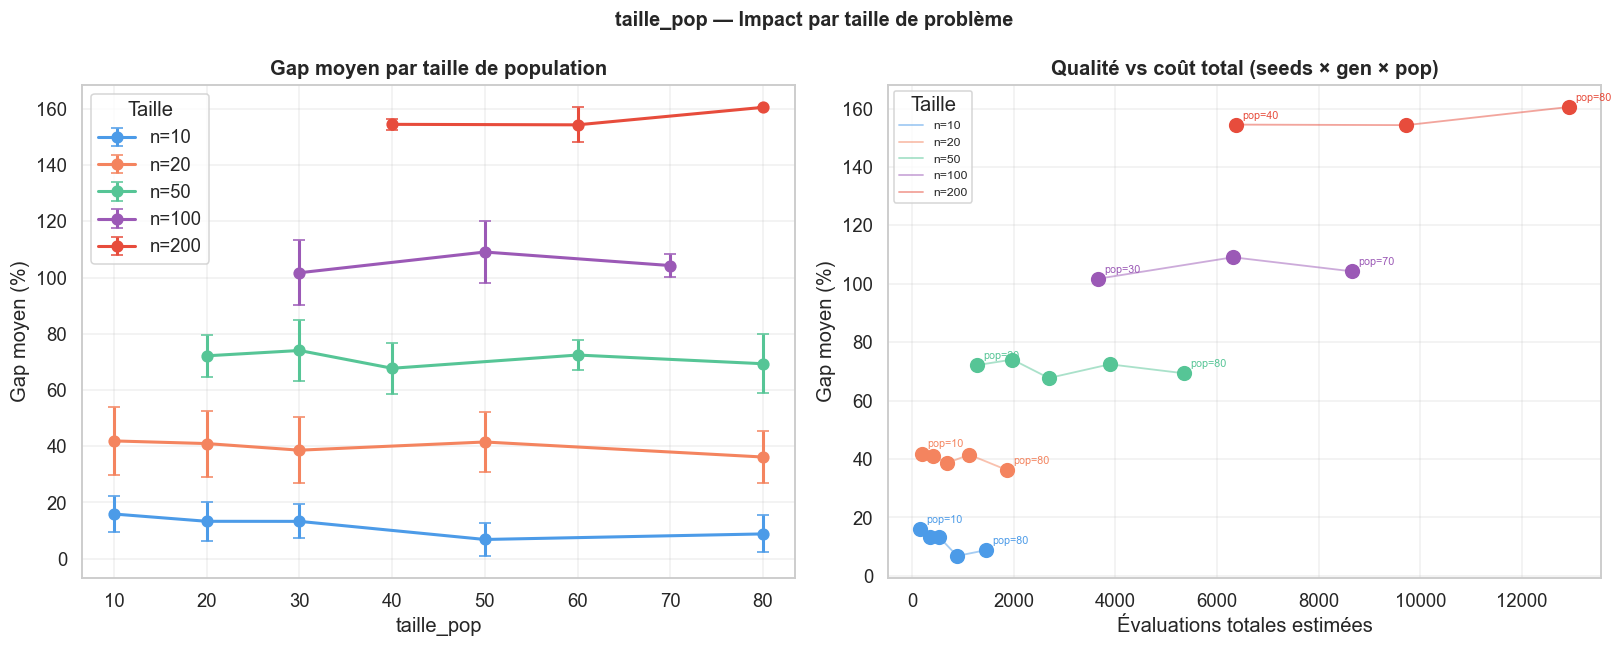


Population optimale par taille :
  n=  10 : pop_opt= 50  gap=+6.84%
  n=  20 : pop_opt= 80  gap=+36.17%
  n=  50 : pop_opt= 40  gap=+67.74%
  n= 100 : pop_opt= 30  gap=+101.72%
  n= 200 : pop_opt= 60  gap=+154.34%


In [4]:
POP_PAR_TAILLE = {
    10:  [10, 20, 30, 50, 80],
    20:  [10, 20, 30, 50, 80],
    50:  [20, 30, 40, 60, 80],
    100: [30, 50, 70],
    200: [40, 60, 80],
}

results_pop = {n: [] for n in TAILLES}

for n in TAILLES:
    gen = BASELINES[n]['n_generations']
    mut = BASELINES[n]['taux_mutation']
    print(f"\nn={n} (gen={gen}, mut={mut}) :")
    for pop in POP_PAR_TAILLE[n]:
        r = run_config(n, taille_pop=pop, n_generations=gen, taux_mutation=mut)
        r['taille_pop'] = pop
        results_pop[n].append(r)
        print(f"  pop={pop:3d}  gap={r['gap_moy']:+6.2f}%  ±{r['gap_std']:.2f}%  t={r['t_moy']:.1f}s")

# ── Visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for n in TAILLES:
    pops    = [r['taille_pop'] for r in results_pop[n]]
    gap_moy = [r['gap_moy']   for r in results_pop[n]]
    gap_std = [r['gap_std']   for r in results_pop[n]]
    c = colors_n[n]
    axes[0].errorbar(pops, gap_moy, yerr=gap_std, fmt='o-',
                     color=c, linewidth=2, capsize=4, markersize=7, label=f'n={n}')

    # Qualité vs temps
    times = [r['t_moy'] * N_SEEDS_PAR_TAILLE[n] * BASELINES[n]['n_generations']
             for r in results_pop[n]]
    axes[1].scatter(times, gap_moy, color=c, s=80, zorder=5)
    axes[1].plot(times, gap_moy, '-', color=c, linewidth=1.2, alpha=0.5, label=f'n={n}')
    for i, (t, g, p) in enumerate(zip(times, gap_moy, pops)):
        if i == 0 or i == len(pops) - 1:
            axes[1].annotate(f'pop={p}', (t, g), textcoords='offset points',
                             xytext=(4, 4), fontsize=7, color=c)

axes[0].set_title('Gap moyen par taille de population', fontweight='bold')
axes[0].set_xlabel('taille_pop')
axes[0].set_ylabel('Gap moyen (%)')
axes[0].legend(title='Taille')

axes[1].set_title('Qualité vs coût total (seeds × gen × pop)', fontweight='bold')
axes[1].set_xlabel('Évaluations totales estimées')
axes[1].set_ylabel('Gap moyen (%)')
axes[1].legend(title='Taille', fontsize=8)

for ax in axes:
    ax.grid(alpha=0.3)

plt.suptitle('taille_pop — Impact par taille de problème', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nPopulation optimale par taille :")
for n in TAILLES:
    best = min(results_pop[n], key=lambda r: r['gap_moy'])
    print(f"  n={n:4d} : pop_opt={best['taille_pop']:3d}  gap={best['gap_moy']:+.2f}%")

---
<a id='5'></a>
## 5. Grid search gen × mut par taille

Heatmap 2D pour chaque taille : on fait varier `n_generations` et `taux_mutation` simultanément.
Permet de voir **l'interaction** entre intensification et diversification selon la taille.


n=10 — grid 4×4 = 16 configs (pop=30) :
  [ 1/16] gen=  50 mut=0.10  gap=+16.23%
  [ 2/16] gen=  50 mut=0.20  gap=+13.62%
  [ 3/16] gen=  50 mut=0.30  gap=+14.72%
  [ 4/16] gen=  50 mut=0.50  gap=+11.61%
  [ 5/16] gen= 100 mut=0.10  gap=+13.58%
  [ 6/16] gen= 100 mut=0.20  gap=+12.60%
  [ 7/16] gen= 100 mut=0.30  gap=+13.28%
  [ 8/16] gen= 100 mut=0.50  gap=+9.28%
  [ 9/16] gen= 200 mut=0.10  gap=+10.59%
  [10/16] gen= 200 mut=0.20  gap=+11.49%
  [11/16] gen= 200 mut=0.30  gap=+11.12%
  [12/16] gen= 200 mut=0.50  gap=+8.00%
  [13/16] gen= 400 mut=0.10  gap=+10.28%
  [14/16] gen= 400 mut=0.20  gap=+10.05%
  [15/16] gen= 400 mut=0.30  gap=+8.24%
  [16/16] gen= 400 mut=0.50  gap=+5.38%

n=20 — grid 4×4 = 16 configs (pop=30) :
  [ 1/16] gen=  50 mut=0.10  gap=+41.36%
  [ 2/16] gen=  50 mut=0.20  gap=+38.37%
  [ 3/16] gen=  50 mut=0.30  gap=+41.25%
  [ 4/16] gen=  50 mut=0.50  gap=+41.50%
  [ 5/16] gen= 100 mut=0.10  gap=+39.55%
  [ 6/16] gen= 100 mut=0.20  gap=+41.28%
  [ 7/16] gen= 100 m

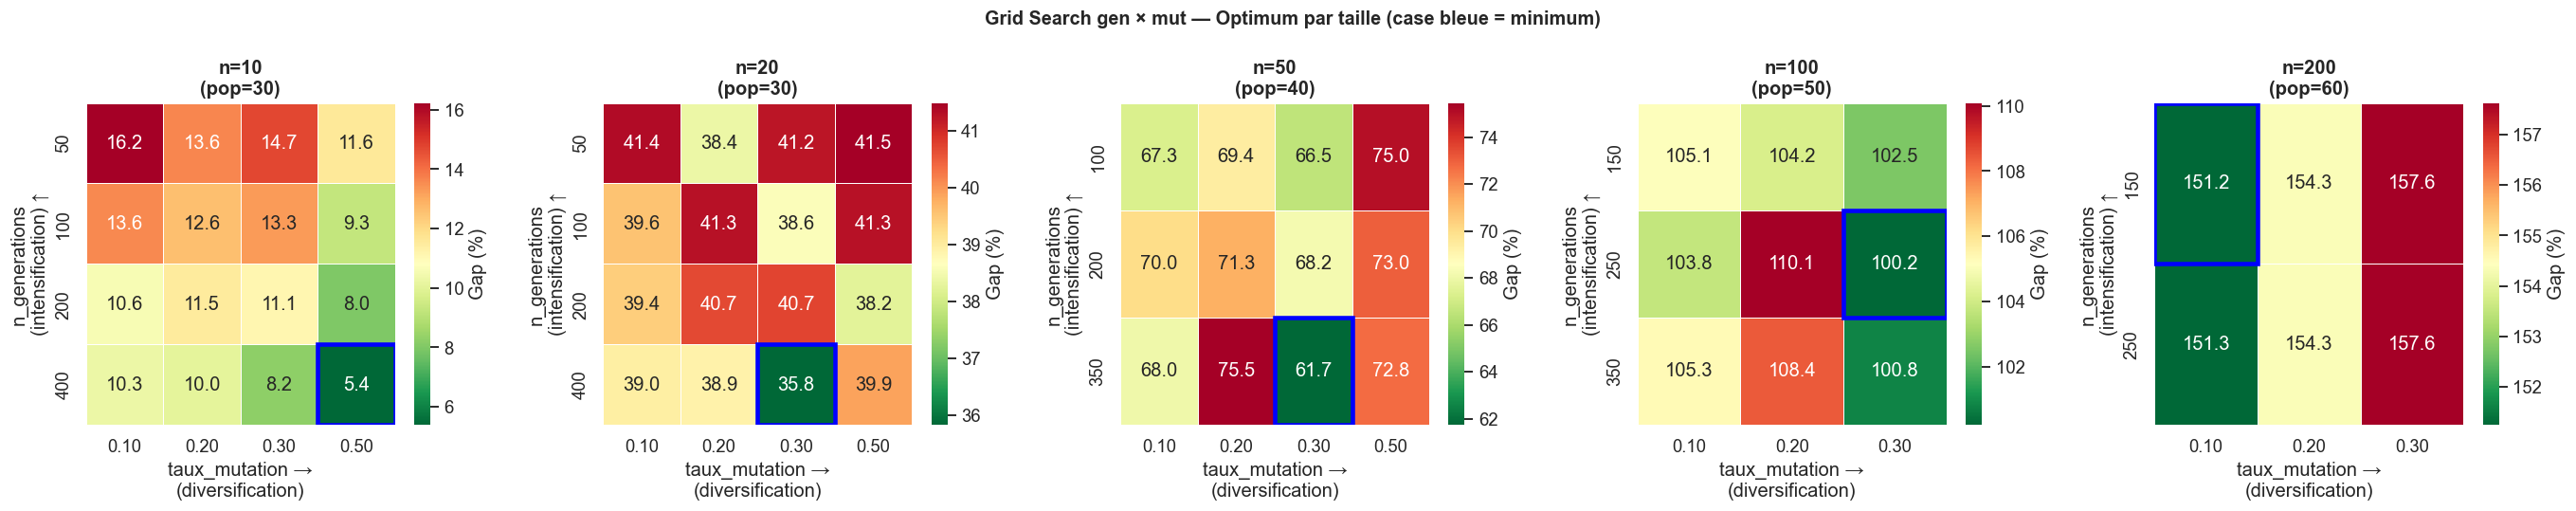


Meilleure combinaison (gen, mut) par taille :
  n=  10 : gen= 400  mut=0.50  gap=+5.38%  (baseline +13.28%)
  n=  20 : gen= 400  mut=0.30  gap=+35.82%  (baseline +38.61%)
  n=  50 : gen= 350  mut=0.30  gap=+61.73%  (baseline +67.74%)
  n= 100 : gen= 250  mut=0.30  gap=+100.22%  (baseline +109.10%)
  n= 200 : gen= 150  mut=0.10  gap=+151.24%  (baseline +154.34%)


In [5]:
# Grilles adaptées par taille pour maîtriser le temps
GRID_PAR_TAILLE = {
    10:  {'gens': [50, 100, 200, 400], 'muts': [0.10, 0.20, 0.30, 0.50]},
    20:  {'gens': [50, 100, 200, 400], 'muts': [0.10, 0.20, 0.30, 0.50]},
    50:  {'gens': [100, 200, 350],     'muts': [0.10, 0.20, 0.30, 0.50]},
    100: {'gens': [150, 250, 350],     'muts': [0.10, 0.20, 0.30]},
    200: {'gens': [150, 250],          'muts': [0.10, 0.20, 0.30]},
}

GRID_RESULTS = {}

for n in TAILLES:
    pop  = BASELINES[n]['taille_pop']
    gens = GRID_PAR_TAILLE[n]['gens']
    muts = GRID_PAR_TAILLE[n]['muts']
    total = len(gens) * len(muts)
    print(f"\nn={n} — grid {len(gens)}×{len(muts)} = {total} configs (pop={pop}) :")

    mat = np.zeros((len(gens), len(muts)))
    done = 0
    for i, gen in enumerate(gens):
        for j, mut in enumerate(muts):
            r = run_config(n, taille_pop=pop, n_generations=gen, taux_mutation=mut)
            mat[i, j] = r['gap_moy']
            done += 1
            print(f"  [{done:2d}/{total}] gen={gen:4d} mut={mut:.2f}  gap={r['gap_moy']:+.2f}%")

    GRID_RESULTS[n] = {'mat': mat, 'gens': gens, 'muts': muts}

# ── Heatmaps une par taille ───────────────────────────────────────
fig, axes = plt.subplots(1, len(TAILLES), figsize=(5 * len(TAILLES), 5))

best_combos = {}
for ax, n in zip(axes, TAILLES):
    gr   = GRID_RESULTS[n]
    mat  = gr['mat']
    gens = gr['gens']
    muts = gr['muts']

    sns.heatmap(mat,
                xticklabels=[f"{m:.2f}" for m in muts],
                yticklabels=[str(g) for g in gens],
                annot=True, fmt='.1f', cmap='RdYlGn_r',
                linewidths=0.5, cbar_kws={'label': 'Gap (%)'},
                ax=ax)

    # Marquer la meilleure cellule
    idx = np.unravel_index(np.argmin(mat), mat.shape)
    ax.add_patch(plt.Rectangle((idx[1], idx[0]), 1, 1,
                                fill=False, edgecolor='blue', linewidth=3))

    ax.set_title(f'n={n}\n(pop={BASELINES[n]["taille_pop"]})', fontweight='bold')
    ax.set_xlabel('taux_mutation →\n(diversification)')
    ax.set_ylabel('n_generations\n(intensification) ↑')

    best_combos[n] = {
        'gen': gens[idx[0]], 'mut': muts[idx[1]], 'gap': mat[idx]
    }

plt.suptitle('Grid Search gen × mut — Optimum par taille (case bleue = minimum)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nMeilleure combinaison (gen, mut) par taille :")
for n in TAILLES:
    bc = best_combos[n]
    base = BASE_RESULTS[n]['gap_moy']
    print(f"  n={n:4d} : gen={bc['gen']:4d}  mut={bc['mut']:.2f}  "
          f"gap={bc['gap']:+.2f}%  (baseline {base:+.2f}%)")

# Sauvegarder pour la section Bilan
BEST_COMBOS = best_combos

---
<a id='6'></a>
## 6. Courbes de convergence comparées

Pour chaque taille, on compare la convergence de la **config baseline** vs la **config optimale** trouvée au grid search.
Cela confirme visuellement que le tuning améliore bien la vitesse de convergence.

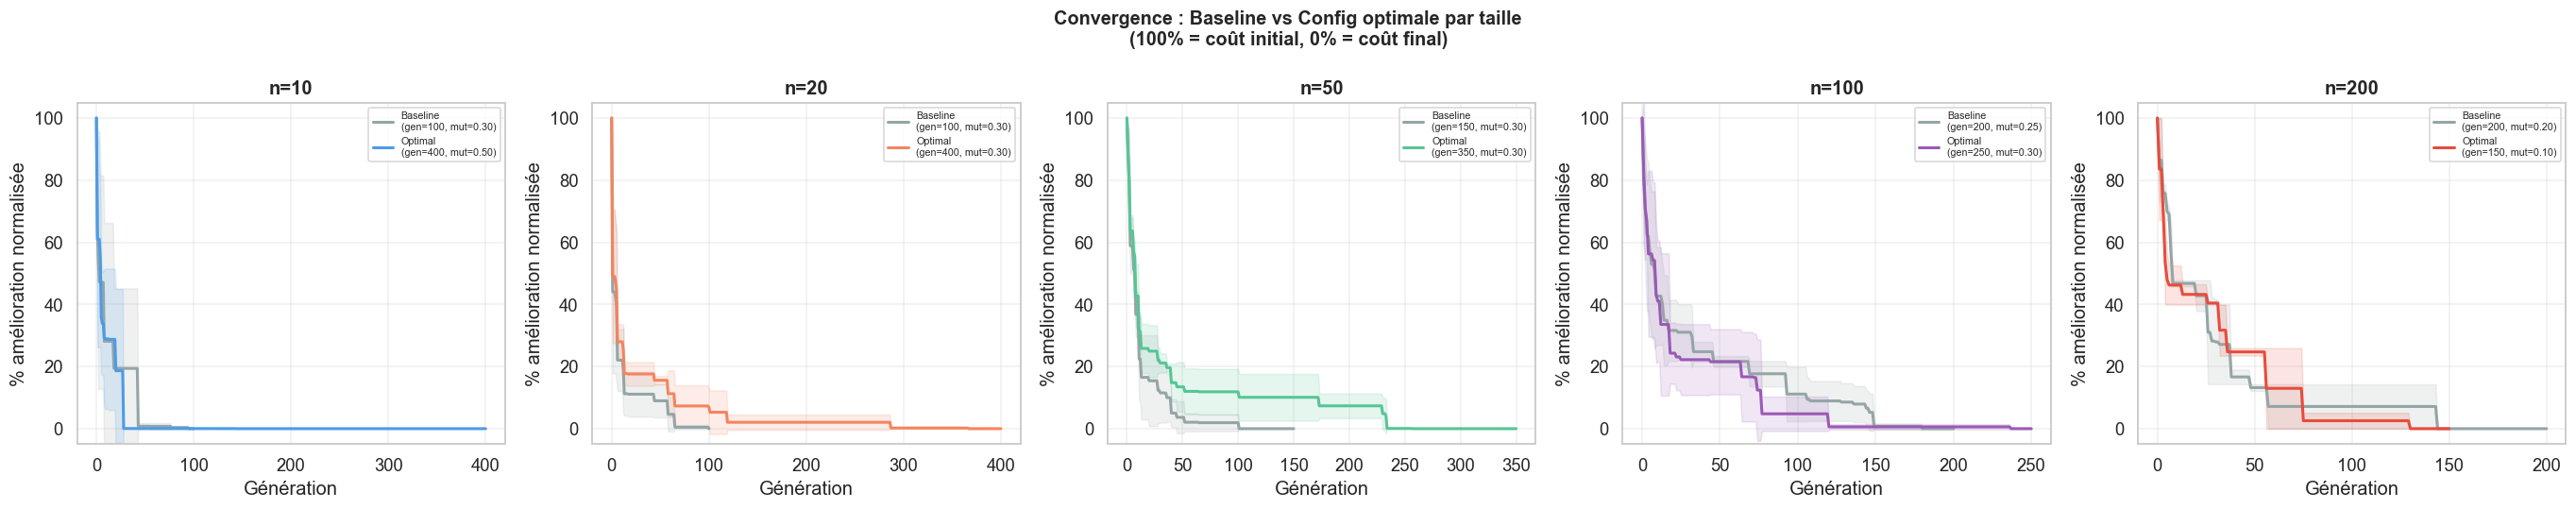

In [6]:
fig, axes = plt.subplots(1, len(TAILLES), figsize=(5 * len(TAILLES), 5))

for ax, n in zip(axes, TAILLES):
    pop_b = BASELINES[n]['taille_pop']
    bc    = BEST_COMBOS[n]

    configs = [
        ('Baseline', dict(taille_pop=pop_b,
                          n_generations=BASELINES[n]['n_generations'],
                          taux_mutation=BASELINES[n]['taux_mutation']),
         '#95A5A6'),
        ('Optimal',  dict(taille_pop=pop_b,
                          n_generations=bc['gen'],
                          taux_mutation=bc['mut']),
         colors_n[n]),
    ]

    for label, cfg, color in configs:
        # Moyenner sur les seeds disponibles
        curves = []
        n_seeds = min(3, N_SEEDS_PAR_TAILLE[n])
        for s in range(n_seeds):
            _, _, hist = algorithme_genetique(
                ALL_INSTANCES[n][s], seed=s, **cfg)
            curve = np.array(hist['couts_generations'])
            # Normaliser : 100% = début, 0% = fin
            rng = curve[0] - curve[-1]
            if rng > 1e-6:
                curve = (curve - curve[-1]) / rng * 100
            else:
                curve = np.zeros_like(curve)
            curves.append(curve)

        min_len = min(len(c) for c in curves)
        arr = np.array([c[:min_len] for c in curves])
        mean, std = arr.mean(0), arr.std(0)
        gens = np.arange(min_len)

        ax.plot(gens, mean, '-', color=color, linewidth=2,
                label=f'{label}\n(gen={cfg["n_generations"]}, mut={cfg["taux_mutation"]:.2f})')
        ax.fill_between(gens, mean - std, mean + std, alpha=0.15, color=color)

    ax.set_title(f'n={n}', fontweight='bold')
    ax.set_xlabel('Génération')
    ax.set_ylabel('% amélioration normalisée')
    ax.set_ylim(-5, 105)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Convergence : Baseline vs Config optimale par taille\n'
             '(100% = coût initial, 0% = coût final)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='7'></a>
## 7. Bilan & Configuration recommandée par taille

=== CONFIGURATIONS RECOMMANDÉES PAR TAILLE ===

 n clients  pop baseline  pop optimale  gen baseline  gen optimale  mut baseline  mut optimale  gap baseline (%)  gap optimal (%)  gain (pts %)
        10            30            50           100           400          0.30           0.5             13.28             5.38          7.90
        20            30            80           100           400          0.30           0.3             38.61            35.82          2.79
        50            40            40           150           350          0.30           0.3             67.74            61.73          6.01
       100            50            30           200           250          0.25           0.3            109.10           100.22          8.88
       200            60            60           200           150          0.20           0.1            154.34           151.24          3.10


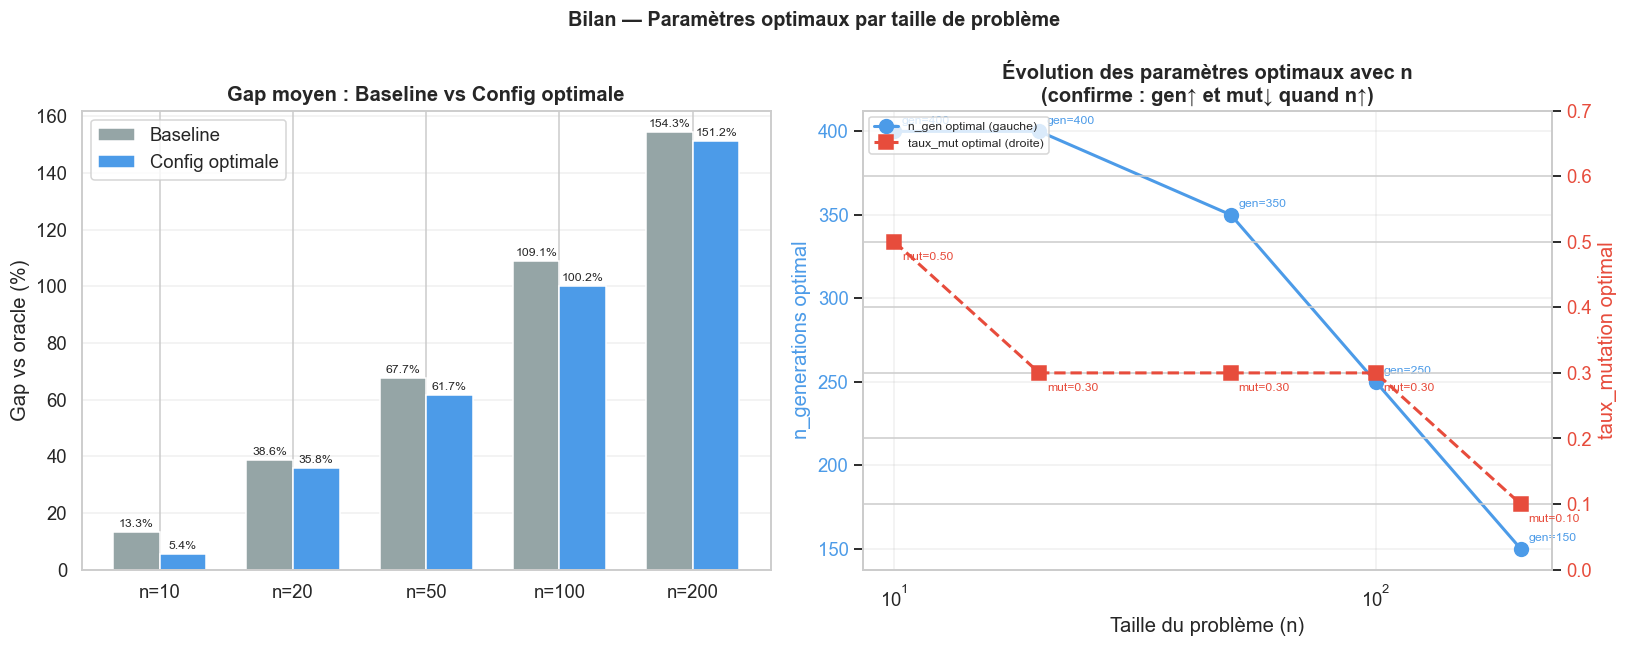


=== RÉSUMÉ — CONFIG À UTILISER PAR TAILLE ===
     n | taille_pop | n_generations | taux_mutation | gap attendu
--------------------------------------------------------------
    10 |         50 |           400 |          0.50 |      +5.38%
    20 |         80 |           400 |          0.30 |     +35.82%
    50 |         40 |           350 |          0.30 |     +61.73%
   100 |         30 |           250 |          0.30 |    +100.22%
   200 |         60 |           150 |          0.10 |    +151.24%


In [7]:
rows = []
for n in TAILLES:
    bc        = BEST_COMBOS[n]
    best_pop  = min(results_pop[n], key=lambda r: r['gap_moy'])
    base      = BASE_RESULTS[n]
    rows.append({
        'n clients'          : n,
        'pop baseline'       : BASELINES[n]['taille_pop'],
        'pop optimale'       : best_pop['taille_pop'],
        'gen baseline'       : BASELINES[n]['n_generations'],
        'gen optimale'       : bc['gen'],
        'mut baseline'       : BASELINES[n]['taux_mutation'],
        'mut optimale'       : bc['mut'],
        'gap baseline (%)'   : round(base['gap_moy'], 2),
        'gap optimal (%)'    : round(bc['gap'], 2),
        'gain (pts %)'       : round(base['gap_moy'] - bc['gap'], 2),
    })

df_bilan = pd.DataFrame(rows)
print("=== CONFIGURATIONS RECOMMANDÉES PAR TAILLE ===\n")
print(df_bilan.to_string(index=False))

# ── Graphique 1 : Gap baseline vs optimal par taille ─────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x = np.arange(len(TAILLES))
w = 0.35
bars_b = axes[0].bar(x - w/2, df_bilan['gap baseline (%)'], w,
                     label='Baseline', color='#95A5A6', edgecolor='white')
bars_o = axes[0].bar(x + w/2, df_bilan['gap optimal (%)'],  w,
                     label='Config optimale', color='#4C9BE8', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'n={n}' for n in TAILLES])
axes[0].set_title('Gap moyen : Baseline vs Config optimale', fontweight='bold')
axes[0].set_ylabel('Gap vs oracle (%)')
axes[0].legend()
axes[0].bar_label(bars_b, fmt='{:.1f}%', padding=2, fontsize=8)
axes[0].bar_label(bars_o, fmt='{:.1f}%', padding=2, fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# ── Graphique 2 : Évolution des paramètres optimaux avec n ────────
ax2 = axes[1]
ax2b = ax2.twinx()

gen_opt = df_bilan['gen optimale'].values
mut_opt = df_bilan['mut optimale'].values

line1, = ax2.plot(TAILLES, gen_opt, 'o-', color='#4C9BE8', linewidth=2,
                  markersize=9, label='n_gen optimal (gauche)')
ax2.set_xlabel('Taille du problème (n)')
ax2.set_ylabel('n_generations optimal', color='#4C9BE8')
ax2.tick_params(axis='y', labelcolor='#4C9BE8')

line2, = ax2b.plot(TAILLES, mut_opt, 's--', color='#E74C3C', linewidth=2,
                   markersize=9, label='taux_mut optimal (droite)')
ax2b.set_ylabel('taux_mutation optimal', color='#E74C3C')
ax2b.tick_params(axis='y', labelcolor='#E74C3C')
ax2b.set_ylim(0, 0.7)

for i, n in enumerate(TAILLES):
    ax2.annotate(f'gen={gen_opt[i]}', (n, gen_opt[i]),
                 textcoords='offset points', xytext=(5, 5), fontsize=8, color='#4C9BE8')
    ax2b.annotate(f'mut={mut_opt[i]:.2f}', (n, mut_opt[i]),
                  textcoords='offset points', xytext=(5, -12), fontsize=8, color='#E74C3C')

ax2.set_title('Évolution des paramètres optimaux avec n\n'
              '(confirme : gen↑ et mut↓ quand n↑)',
              fontweight='bold')
ax2.legend(handles=[line1, line2], loc='upper left', fontsize=8)
ax2.grid(alpha=0.3)
ax2.set_xscale('log')

plt.suptitle('Bilan — Paramètres optimaux par taille de problème',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Résumé final ──────────────────────────────────────────────────
print("\n=== RÉSUMÉ — CONFIG À UTILISER PAR TAILLE ===")
print(f"{'n':>6} | {'taille_pop':>10} | {'n_generations':>13} | {'taux_mutation':>13} | {'gap attendu':>11}")
print('-'*62)
for _, row in df_bilan.iterrows():
    print(f"  {int(row['n clients']):4d} | {int(row['pop optimale']):>10d} | "
          f"{int(row['gen optimale']):>13d} | {row['mut optimale']:>13.2f} | "
          f"{row['gap optimal (%)']:>+10.2f}%")